# SIV Project: Board Game Analysis
**Students:** Federico Berra and Davide Verzotto

## Environment Setup & Tools
This section imports the required libraries and defines utility functions for image visualization. These helper functions are used throughout the notebook to display intermediate and final processing results. The loaded image serves as the starting point for the board detection pipeline.

Setup Complete. Tools are ready!
Loaded: 004.png


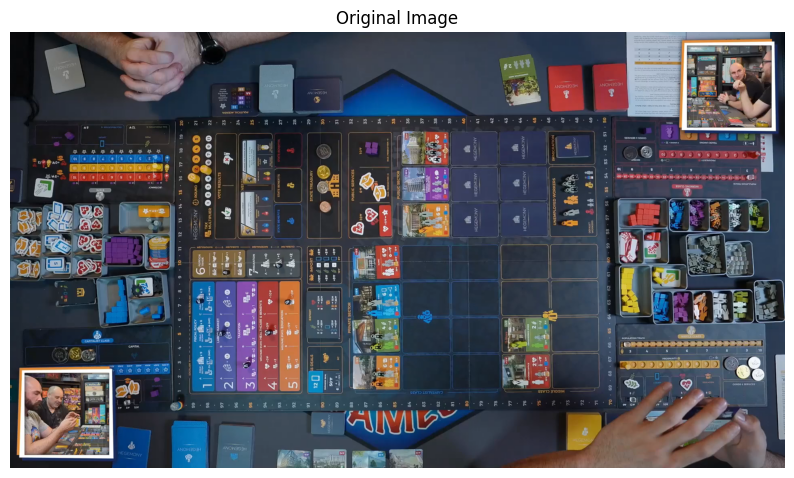

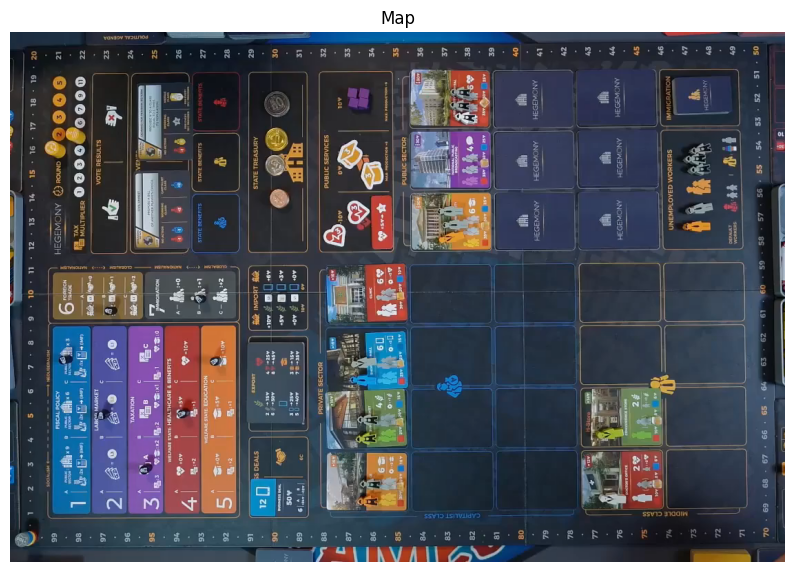

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10,8))

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


folder_path = "../dataset/Game_1/"

image_name = sorted(os.listdir(folder_path))[1]
img_path = os.path.join(folder_path, image_name)
img = cv2.imread(img_path)

# Find map 
x = 390
y = 190
w = 1125
h = 770
map = img[y:y+h, x:x+w]


print("Setup Complete. Tools are ready!")
print("Loaded:", image_name)
show_image(img, "Original Image")
show_image(map, "Map")

## Preprocessing
A 2x3 grid is plotted to compare three different preprocessing pipelines alongside their corresponding intensity histograms. This visualization step demonstrates that a direct median filter suppresses internal textures and text without amplifying lighting reflections, improving the robustness of subsequent edge detection

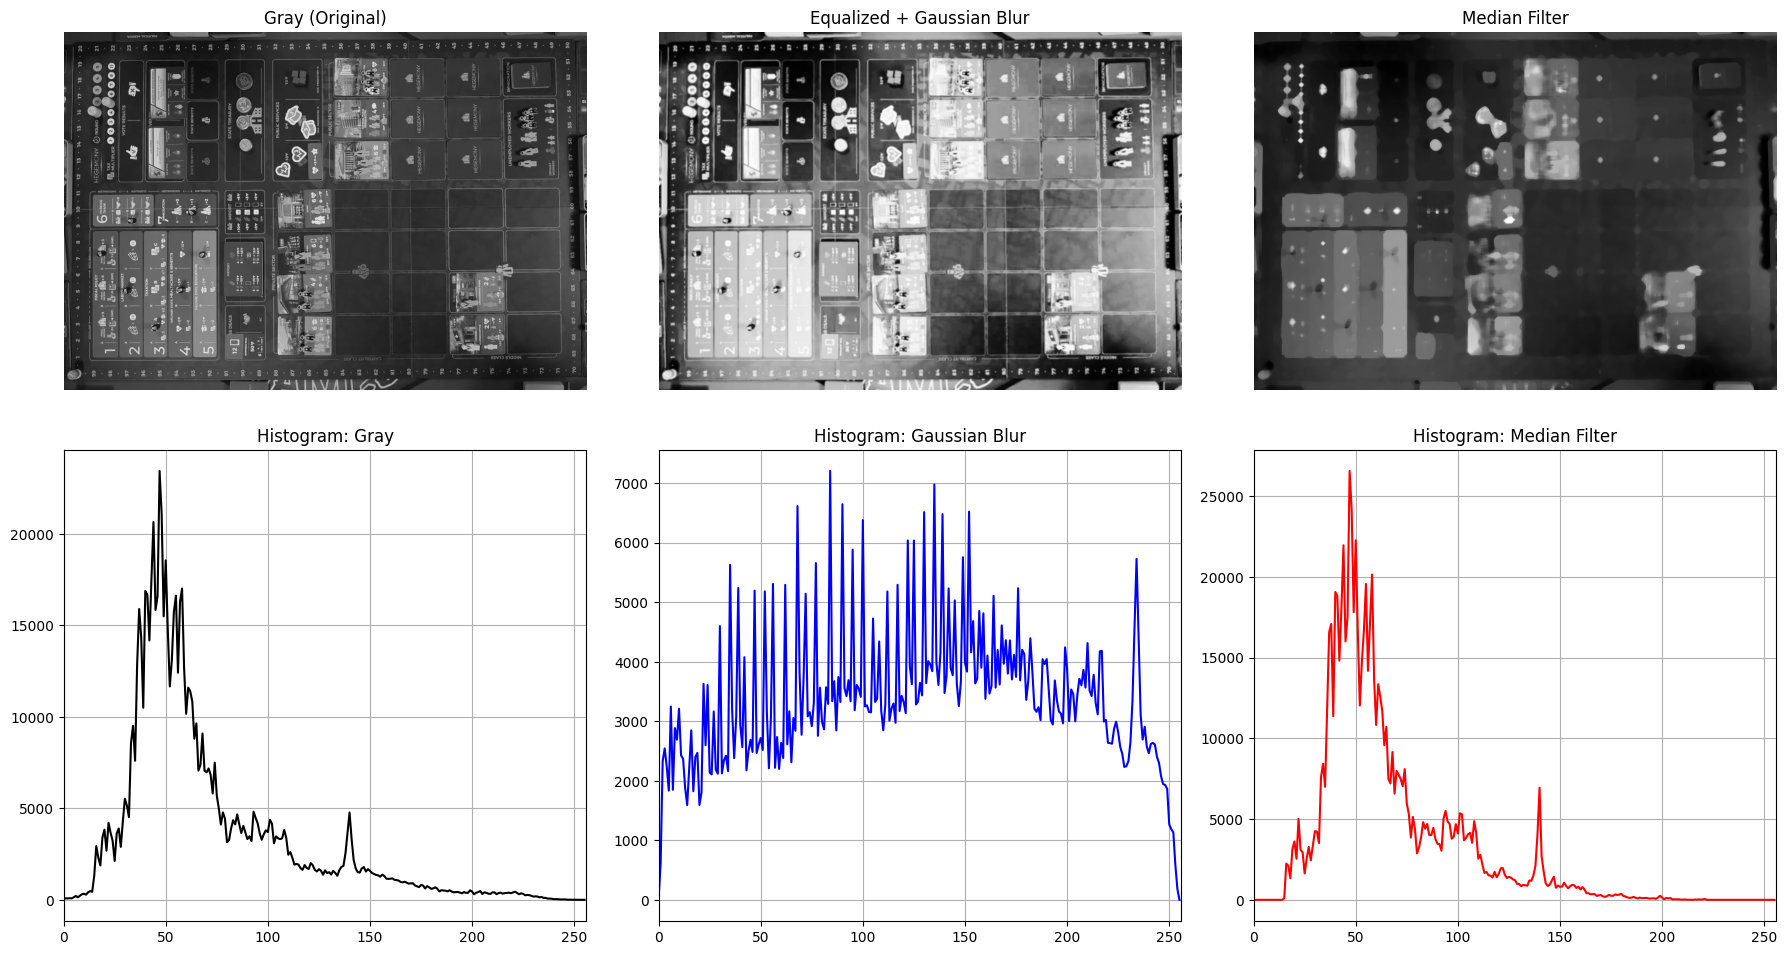

In [32]:
gray = cv2.cvtColor(map, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)
blur_gaussian = cv2.GaussianBlur(equalized, (5, 5), 0)
blur_median = cv2.medianBlur(gray, 15)

hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist_gaussian = cv2.calcHist([blur_gaussian], [0], None, [256], [0, 256])
hist_median = cv2.calcHist([blur_median], [0], None, [256], [0, 256])

# Display
plt.figure(figsize=(18, 10))

# Images
plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Gray (Original)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(blur_gaussian, cmap='gray')
plt.title("Equalized + Gaussian Blur")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(blur_median, cmap='gray')
plt.title("Median Filter")
plt.axis("off")

# Histogrames
plt.subplot(2, 3, 4)
plt.plot(hist_gray, color='black')
plt.title("Histogram: Gray")
plt.xlim([0, 256])
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(hist_gaussian, color='blue')
plt.title("Histogram: Gaussian Blur")
plt.xlim([0, 256])
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(hist_median, color='red')
plt.title("Histogram: Median Filter")
plt.xlim([0, 256])
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation of Edge Detection Operators vs. Color Segmentation
We experimented with different edge detection operators studied during the laboratories (**Roberts, Sobel, and Laplacian**) to verify if they could assist in extracting token boundaries.

Processing manual operators...
Processing complete!


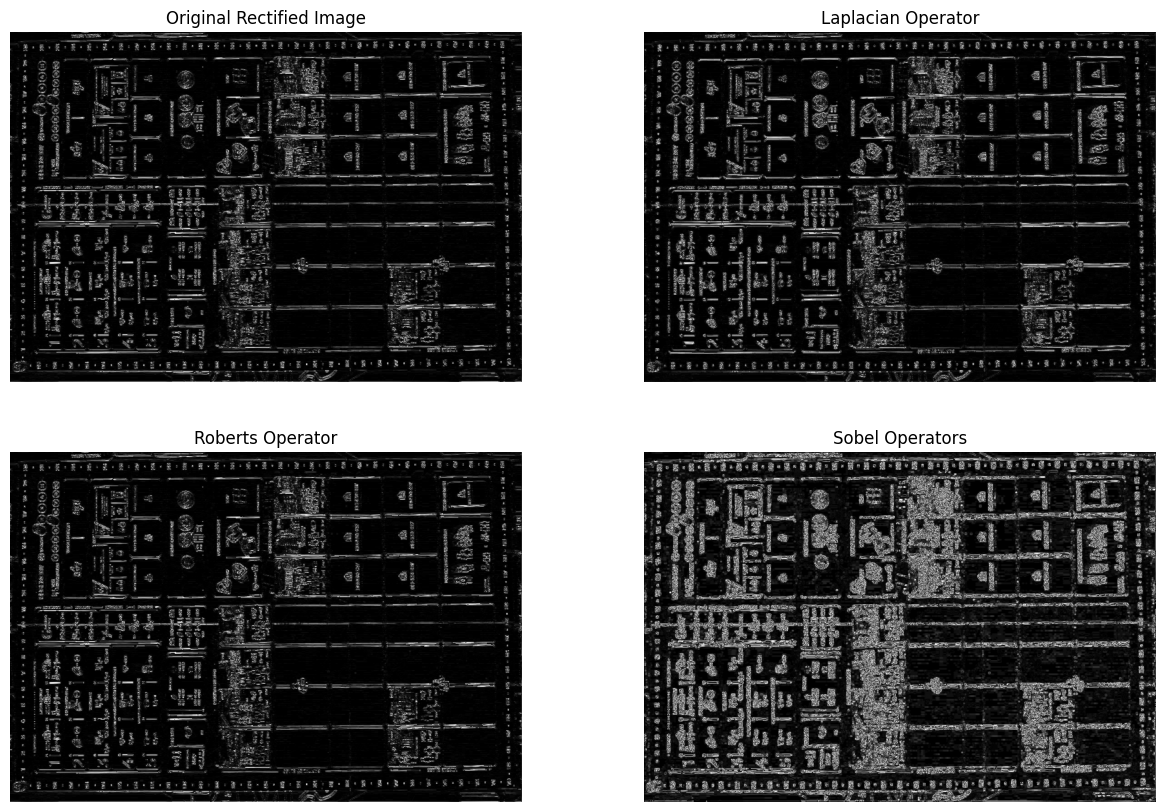

In [40]:
# Robert Operator
def robert(img):
    r, c = img.shape
    r_sunnzi = [[-1,-1],[1,1]]
    for x in range(r):
        for y in range(c):
            if (y + 2 <= c) and (x + 2 <= r):
                imgChild = img[x:x+2, y:y+2]
                list_robert = r_sunnzi*imgChild
                img[x, y] = abs(list_robert.sum()) # sum and absolute value
    return img

# Sobel Operator
def sobel(img):
    r, c = img.shape
    new_image = np.zeros((r, c))
    new_imageX = np.zeros(img.shape)
    new_imageY = np.zeros(img.shape)
    s_suanziX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]) # X direction
    s_suanziY = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])     
    
    for i in range(r-2):
        for j in range(c-2):
            new_imageX[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * s_suanziX))
            new_imageY[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * s_suanziY))
            new_image[i+1, j+1] = (new_imageX[i+1, j+1]**2 + new_imageY[i+1, j+1]**2)**0.5

    return np.uint8(new_image) # The image processed by the directionless operator

# Laplace Operator
def laplace(img):
    r, c = img.shape
    new_image = np.zeros((r, c))
    L_sunnzi = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])          
    for i in range(r-2):
        for j in range(c-2):
            new_image[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * L_sunnzi))
    return np.uint8(new_image)

print("Processing manual operators...")
img_laplace = laplace(gray)
img_robert  = robert(gray)
img_sobel   = sobel(gray)
print("Processing complete!")

plt.figure(figsize=(15, 10))

plt.subplot(221)
plt.title("Original Rectified Image")
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.axis('off')

plt.subplot(222)
plt.title("Laplacian Operator")
plt.imshow(img_laplace, cmap="gray", vmin=0, vmax=255)
plt.axis('off')

plt.subplot(223)
plt.title("Roberts Operator")
plt.imshow(img_robert, cmap="gray", vmin=0, vmax=255)
plt.axis('off')

plt.subplot(224)
plt.title("Sobel Operators")
plt.imshow(img_sobel, cmap="gray", vmin=0, vmax=255)
plt.axis('off')

plt.show()


## Edge Detection 
The Canny edge detector is applied to identify significant intensity transitions in the image. These edges provide the structural information required for line detection and board boundary estimation.

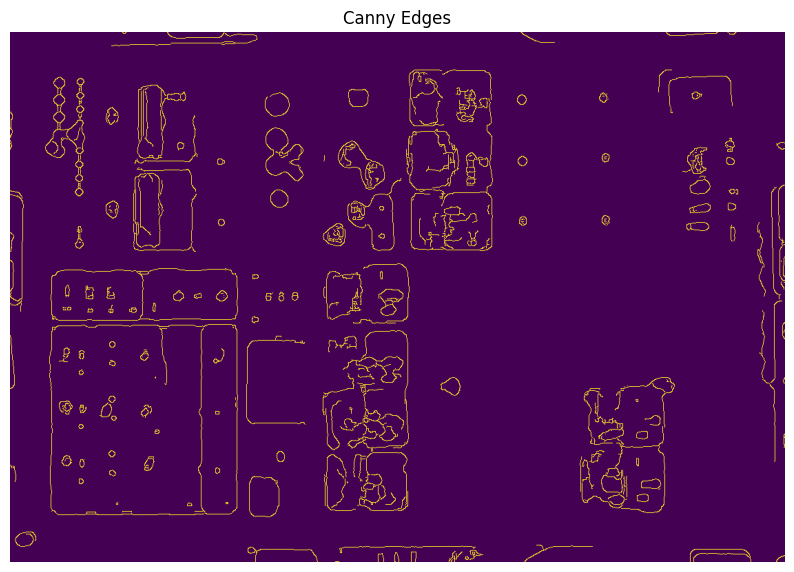

In [35]:
edges = cv2.Canny(blur_median, 30, 100)

show_image(edges, "Canny Edges") # if you want black and white use (...,cmap='gray')